# Drone pad
### Door
Jasper Wijmstra & Sven Welink

### Inhoud

Dit notebook dient als aanvulling op het bijbehorende verslag van dynamische systemen

### Importeer biliotheken

In [1]:
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Constante waarden
L = 10 # Startpunt 
p = 1 # Snelheid in m/s

### Continu aanpassende richting
De formule voor de vliegroute van de drone die zijn richting continu aanpast ziet er als volgt uit: 

$\frac{x^2-L^2}{4L}  - \frac{L}{2}ln(\frac{x}{L})$

In [3]:
def AanpassenContinu(x, L):
    return (((x**2-L**2) / (4*L)) - (L/2) * np.log(x/L))

Bekijk het plotje 

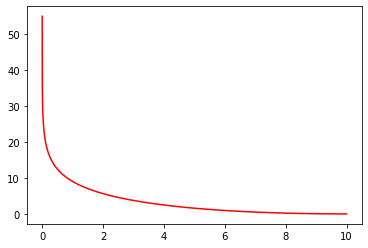

In [4]:
# Interval voor x op 0,0001 tot en met 10
x = np.linspace(0.0001,10,10000) 

plt.plot(x, AanpassenContinu(x,L),color='red')

### In stappen
Maak een functie voor de coördinaten op basis van de vorige coördinaten

In [5]:
def VolgendeStap(x ,y ,n ,q):
    # Bereken de volgende x,y coordinaten
    x_nieuw = x - (x/ ((x**2) + (y - (n-1)*p*q)**2)**.5)*p*q
    y_nieuw = y - (y-(n-1)*p*q)/((x**2+(y-(n-1)*p*q)**2)**.5)*p*q
    return x_nieuw, y_nieuw

Maak een functie die deze stap blijft herhalen

In [6]:
def InStappen(q, L, stop=0.01):
    # bereken de coordinaten van de stappen tot en met 1cm afstand
    # Geef de startwaarde voor x en y en de n-stap
    x, y, stap = L, 0, 1
    
    # Lijsten voor coordianten
    x_coord = [x]
    y_coord = [y]
    
    while x > stop: # herhaal zolang x groter is dan de stop waarde
        # Bepaal de volgende x, y en n
        x, y = VolgendeStap(x, y, stap, q)
        stap += 1
        
        # sla de nieuwe x,y op
        x_coord.append(x)
        y_coord.append(y)
        
    return x_coord, y_coord

Test of de functie werkt

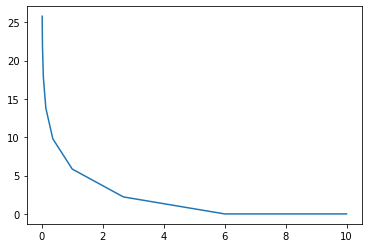

In [7]:
X_lijst, Y_lijst = InStappen(4, L)

plt.plot(X_lijst, Y_lijst)

### Verschillende plotjes

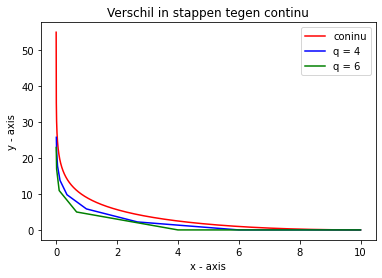

In [8]:
plt.plot(x, AanpassenContinu(x,L),color='red', label="coninu")

X_lijst, Y_lijst = InStappen(4, L)
plt.plot(X_lijst, Y_lijst, color="blue", label="q = 4")

X_lijst, Y_lijst = InStappen(6, L)
plt.plot(X_lijst, Y_lijst, color="green", label="q = 6")

# Set the x axis label of the current axis.
plt.xlabel('x - axis')
# Set the y axis label of the current axis.
plt.ylabel('y - axis')
# Set a title of the current axes.
plt.title('Verschil in stappen tegen continu')
# show a legend on the plot
plt.legend()
# Display a figure.
plt.show()

### Maak een widget voor plotjes

In [9]:
import ipywidgets as widgets
from IPython.display import clear_output # Gebruik deze functie om de output weer leeg te maken

# Sliders
Startwaarde = widgets.FloatSlider(value=10, min=0.01, max = 25, description = "L")
Ververstijd = widgets.FloatSlider(value=1, min =0.1, max = 10, description = "q")

# Knop voor het starten
knop = widgets.Button(description="Run")

# Plek voor uitvoer
out = widgets.Output(layout={'border': '1px solid black'})

# Zorg ervoor dat het programma gaat uitvoeren bij een druk op de knop
def on_knop_clicked(b):
    # Maak de output leeg
    out.clear_output()
    
    with out: # Voer in de ouput ruimte de plot uit
        x = np.linspace(0.0001,Startwaarde.value,10000) 
        plt.plot(x, AanpassenContinu(x, Startwaarde.value), color='red', label="coninu")

        X_lijst, Y_lijst = InStappen(Ververstijd.value, Startwaarde.value)
        plt.plot(X_lijst, Y_lijst, color="blue", label=str('q = ' + str(Ververstijd.value)))

        # Set the x axis label of the current axis.
        plt.xlabel('x - axis')
        # Set the y axis label of the current axis.
        plt.ylabel('y - axis')
        # Set a title of the current axes.
        plt.title('Verschil in stappen tegen continu')
        # show a legend on the plot
        plt.legend()
        # Display a figure.
        plt.show()
    
knop.on_click(on_knop_clicked) # koppelen van subroutine aan de 'on_click' event van de buttobn widget


In [10]:
# Display widget
display(Startwaarde, Ververstijd, knop, out)

FloatSlider(value=10.0, description='L', max=25.0, min=0.01)

FloatSlider(value=1.0, description='q', max=10.0, min=0.1)

Button(description='Run', style=ButtonStyle())

Output(layout=Layout(border='1px solid black'))